### Visual comparison, using tensors

In [28]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from src.io_utils import load_rgb_tensor
from src.compression import compress_grayscale
from src.metrics import compression_ratio, psnr, ssim
import tensorly as tl
from tensorly.decomposition import tucker

In [31]:
image_path = PROJECT_ROOT / "data" / "raw" / "human.jpg"
print(image_path)
print(image_path.exists())

image_rgb = load_rgb_tensor(str(image_path))

/Users/aleksandramakszewska/SVD-image-compression/data/raw/human.jpg
True


In [55]:
weights = [
    [10, 10, 3],
    [30, 30, 3],
    [50, 50, 3],
    [70, 70, 3],
    [100, 100, 3]
]

results = []

for weight in weights:
    core_i, factors_i = tucker(image_rgb, rank=weight)
    reconstructed_i = tl.tucker_to_tensor((core_i, factors_i))
    reconstructed_i = np.clip(reconstructed_i, 0, 255).astype(np.uint8)

    current_cr = compression_ratio(image_rgb.shape, weight[0])
    current_psnr = psnr(image_rgb, reconstructed_i)
    current_ssim = ssim(image_rgb, reconstructed_i)

    print(
        f'Weight {weight}: '
        f'CR={current_cr:.2f}, '
        f'PSNR={current_psnr:.2f}, '
        f'SSIM={current_ssim:.3f}'
    )

    results.append((weight, reconstructed_i, current_cr, current_psnr, current_ssim))

Weight [10, 10, 3]: CR=23.98, PSNR=31.15, SSIM=0.778
Weight [30, 30, 3]: CR=7.99, PSNR=33.68, SSIM=0.871
Weight [50, 50, 3]: CR=4.80, PSNR=35.78, SSIM=0.918
Weight [70, 70, 3]: CR=3.43, PSNR=37.71, SSIM=0.946
Weight [100, 100, 3]: CR=2.40, PSNR=40.09, SSIM=0.967


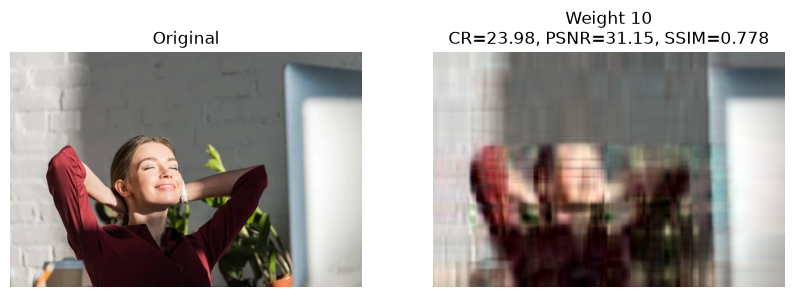

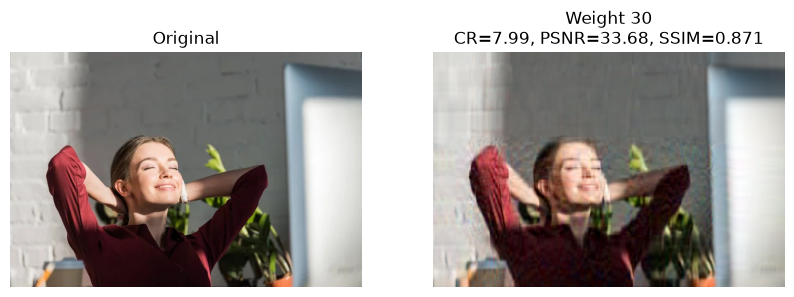

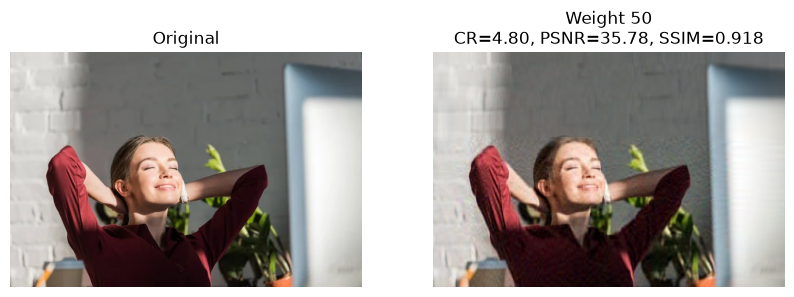

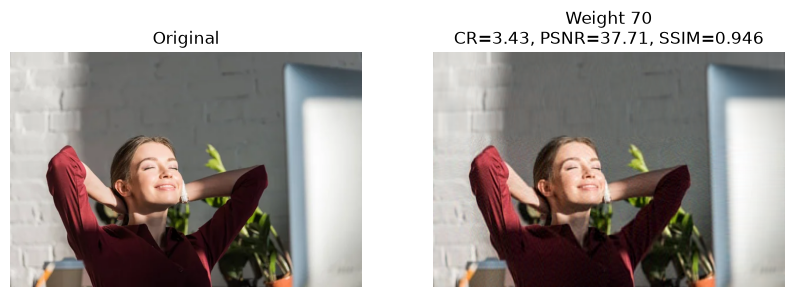

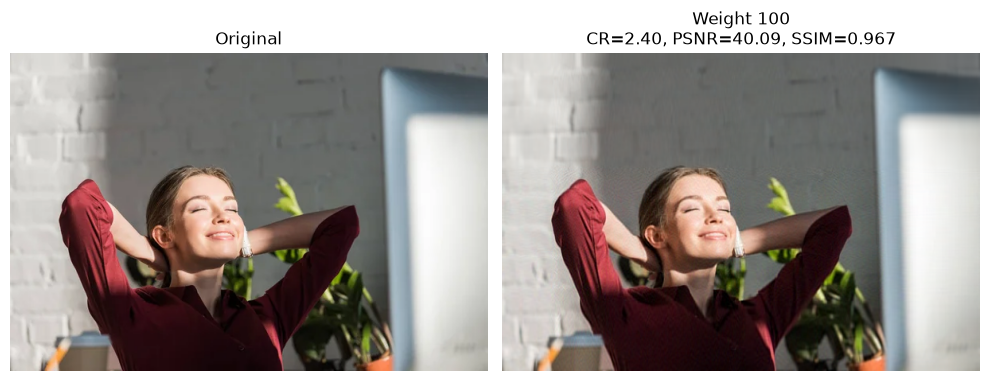

In [57]:
for i, (weight, reconstructed_i, current_cr, current_psnr, current_ssim) in enumerate(results, start=1):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image_rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(reconstructed_i)
    plt.title(
        f'Weight {weight[0]}\n'
        f'CR={current_cr:.2f}, PSNR={current_psnr:.2f}, SSIM={current_ssim:.3f}'
    )
    plt.axis("off")

plt.tight_layout()
plt.show()